### Trasnformer와 GPT1의 다른점
1. 트랜스포머는 encoder-decoder구조이기 때문에 encoder input, decoder input 이 필요한데, 

GPT1은 decoder만 수직으로 쌓아올려 사용하므로 decoder input만 필요하는 등의 구조의 차이점이 존재한다. 

즉, cross attention(encoder-decoder attention) 이 gpt1에서는 수행되지 않는다.


2. 그리고 positional encoding 방식도 다르다. GPT1에서는

```
nn.Embedding(max_pos, d_model)
```
을 사용하여, 위치 정보 자체도 학습이 가능하도록 positional embedding을 사용한다.

3. 활성화함수의 차이도 존재한다. GPT-1에서는 ReLU -> GELU를 도입해 사용했다.




In [45]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [46]:
%cd /content/drive/MyDrive/스크래치/data

/content/drive/MyDrive/스크래치/data


In [47]:
!wget https://github.com/songys/Chatbot_data/raw/master/ChatbotData.csv

--2026-02-09 06:14:34--  https://github.com/songys/Chatbot_data/raw/master/ChatbotData.csv
Resolving github.com (github.com)... 140.82.121.4
Connecting to github.com (github.com)|140.82.121.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/songys/Chatbot_data/master/ChatbotData.csv [following]
--2026-02-09 06:14:34--  https://raw.githubusercontent.com/songys/Chatbot_data/master/ChatbotData.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 889842 (869K) [text/plain]
Saving to: ‘ChatbotData.csv.2’

ChatbotData.csv.2   100%[===================>] 868.99K  --.-KB/s    in 0.03s   

2026-02-09 06:14:34 (33.7 MB/s) - ‘ChatbotData.csv.2’ saved [889842/889842]



In [48]:
# !pip install torchinfo

In [49]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
import torch.optim as optim
import torch.optim.lr_scheduler as lr_scheduler
import sentencepiece as spm

import math
import os
import re
import urllib.request
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [50]:
df = pd.read_csv('/content/drive/MyDrive/스크래치/data/ChatbotData.csv')
df

,Q,A,label
0,12시 땡!,하루가 또 가네요.,0
1,1지망 학교 떨어졌어,위로해 드립니다.,0
2,3박4일 놀러가고 싶다,여행은 언제나 좋죠.,0
3,3박4일 정도 놀러가고 싶다,여행은 언제나 좋죠.,0
4,PPL 심하네,눈살이 찌푸려지죠.,0
...,...,...,...
11818,훔쳐보는 것도 눈치 보임.,티가 나니까 눈치가 보이는 거죠!,2
11819,훔쳐보는 것도 눈치 보임.,훔쳐보는 거 티나나봐요.,2
11820,흑기사 해주는 짝남.,설렜겠어요.,2
11821,힘든 연애 좋은 연애라는게 무슨 차이일까?,잘 헤어질 수 있는 사이 여부인 거 같아요.,2


### 데이터 전처리

In [7]:
import re
# 전처리 함수
def preprocess_sentence(sentence):
  # 입력받은 sentence 양쪽 공백을 제거
  sentence = sentence.strip()

  # 단어와 구두점(punctuation) 사이의 거리를 만듭니다.
  sentence = re.sub(r"([?.!,])", r" \1 ", sentence)
  sentence = re.sub(r'[" "]+', " ", sentence)

  # (한글, 숫자, ".", "?", "!", ",")를 제외한 모든 문자를 공백인 ' '로 대체합니다.
  sentence = re.sub(r"[^ㄱ-ㅎㅏ-ㅣ가-힣0-9?.!,]+", " ", sentence)
  sentence = sentence.strip()
  return sentence


In [8]:
from tqdm import tqdm

for i in tqdm(range(len(df))):

    df.loc[i, 'Q'] = preprocess_sentence(df.loc[i, 'Q'])
    df.loc[i, 'A'] = preprocess_sentence(df.loc[i, 'A'])

df.drop_duplicates(subset=['Q'], inplace=True)
df = df.replace('', pd.NA)
df = df.dropna(how = 'any')
df.reset_index(drop=True, inplace=True)



100%|██████████| 11823/11823 [00:21<00:00, 545.04it/s]


문장의 최단 길이: 1
문장의 최장 길이: 57
문장의 평균 길이: 13


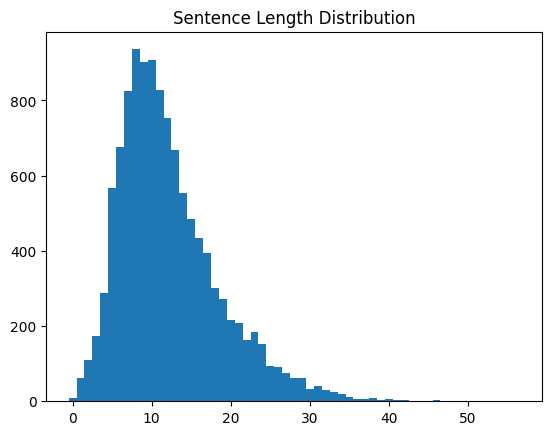

In [9]:
import matplotlib.pyplot as plt
min_len = 999
max_len = 0
sum_len = 0

for sen in df['Q']:
    length = len(sen)
    if min_len > length: min_len = length
    if max_len < length: max_len = length
    sum_len += length

print("문장의 최단 길이:", min_len)
print("문장의 최장 길이:", max_len)
print("문장의 평균 길이:", sum_len // len(df['Q']))

sentence_length = np.zeros((max_len), dtype=int)

for sen in df['Q']:
    sentence_length[len(sen)-1] += 1

plt.bar(range(max_len), sentence_length, width=1.0)
plt.title("Sentence Length Distribution")
plt.show()

In [10]:
def check_sentence_with_length(raw, length):
    count = 0

    for sen in raw:
        if len(sen) == length:
            print(sen)
            count += 1
            if count > 100: return

print( '길이가 1인 text 확인')
print('===Q====')
check_sentence_with_length(df['Q'], 1)

print('===A===')
check_sentence_with_length(df['A'], 1)

길이가 1인 text 확인
===Q====
야
음
응
헉
왜
후
휴
흠
===A===
네
음
네
음
네


In [12]:
# 1이하 길이의 text 삭제
df = df[df['Q'].str.len() > 1]
df = df[df['A'].str.len() > 1]

print('전처리 후 길이가 1이하인 Text: ', check_sentence_with_length(df['Q'], 1), check_sentence_with_length(df['A'], 1))

전처리 후 길이가 1이하인 Text:  None None


### Pairs 데이터 생성

In [13]:
pairs = list(df[['Q', 'A']].itertuples(index=False, name=None))
print('전체 샘플 수 :', len(pairs))

전체 샘플 수 : 11650


### Tokenizer SentencePiece 모델 학습

In [14]:
corpus_file = "clean_corpus.txt"
with open(corpus_file, 'w', encoding='utf-8') as f:
    for q, a in pairs:
        f.write(q + "\n")
        f.write(a + "\n")

In [15]:
spm.SentencePieceTrainer.Train(
    input=corpus_file,
    model_prefix="spm_ko_chat",
    vocab_size=10000,
    character_coverage=1.0,
    model_type="bpe",
    max_sentence_length=999999,
    bos_id=1,  # <s> (Beginning of Sentence) 설정
    eos_id=2,  # </s> (End of Sentence) 설정
    pad_id=0,  # Padding ID 설정
    unk_id=3   # Unknown Token ID 설정
)

In [16]:
sp = spm.SentencePieceProcessor()
sp.Load("spm_ko_chat.model")

# 예제 문장
sentence = "나는 점심을 10분전에 먹어서 매우 졸려.."

sentence = preprocess_sentence(sentence)
print("전처리 후의 문장:", sentence)

# 1. 토크나이징 (subword 단위로 분할)
tokens = sp.encode(sentence, out_type=str)
print("Tokenized:", tokens)

# 2. 인코딩 (서브워드를 정수 ID로 변환)
encoded = sp.encode(sentence, out_type=int)
print("Encoded:", encoded)

# 3. 디코딩 (정수 ID → 원본 문장 복원)
decoded = sp.decode(encoded)
print("Decoded:", decoded)

전처리 후의 문장: 나는 점심을 10분전에 먹어서 매우 졸려 . .
Tokenized: ['▁나는', '▁점심', '을', '▁10', '분', '전에', '▁먹어', '서', '▁매', '우', '▁졸려', '▁.', '▁.']
Encoded: [688, 1810, 8797, 1508, 8905, 2496, 742, 8821, 344, 8915, 2085, 4, 4]
Decoded: 나는 점심을 10분전에 먹어서 매우 졸려 . .


In [17]:
q_list = []
a_list = []
for q_text, a_text in pairs:
    # 1) 토크나이즈
    q_ids = sp.EncodeAsIds(q_text)
    a_ids = sp.EncodeAsIds(a_text)
    q_list.append(q_ids)
    a_list.append(a_ids)

total_data_text = list(q_list+a_list)
# 텍스트데이터 문장길이의 리스트를 생성한 후
num_tokens = [len(tokens) for tokens in total_data_text]
num_tokens = np.array(num_tokens)


# 문장길이의 평균값, 최대값, 표준편차를 계산해 본다.
print('문장길이 평균 : ', np.mean(num_tokens))
print('문장길이 최대 : ', np.max(num_tokens))
print('문장길이 표준편차 : ', np.std(num_tokens))

# 예를들어, 최대 길이를 (평균 + 2*표준편차)로 한다면,
max_tokens = np.mean(num_tokens) + 2 * np.std(num_tokens)
maxlen = int(max_tokens)
print('pad_sequences maxlen : ', maxlen)
print(f'전체 문장의 {np.sum(num_tokens < max_tokens) / len(num_tokens)}%가 maxlen 설정값 이내에 포함됩니다. ')


문장길이 평균 :  5.3601716738197425
문장길이 최대 :  29
문장길이 표준편차 :  2.3690732629098954
pad_sequences maxlen :  10
전체 문장의 0.9671673819742489%가 maxlen 설정값 이내에 포함됩니다. 


### 데이터 셋 구성

In [18]:
class KoChatDataset(Dataset):
    def __init__(self, pairs, sp, max_length=10):
        super().__init__()
        self.sp = sp
        self.max_length = max_length
        self.data = []

        for q_text, a_text in pairs:
            # 1) 토크나이즈
            q_ids = sp.EncodeAsIds(q_text)
            a_ids = sp.EncodeAsIds(a_text)

            # 2) [CLS]/[SEP] 같은 별도 스페셜 토큰을 쓸 수도 있으나,
            #    여기서는 SentencePiece 기본 <s>, </s> 등 혹은 사용자 정의 토큰 활용 가능
            #    간단히 <s>=sp.bos_id(), </s>=sp.eos_id()로 가정해본다면:
            #    sp.SetEncodeExtraOptions("bos:eos") 등으로 설정하는 방법도 있음.
            # 여기서는 수동으로 bos/eos id를 붙인다고 가정
            bos_id = sp.bos_id() if sp.bos_id() >= 0 else 1  # 혹은 임의값
            eos_id = sp.eos_id() if sp.eos_id() >= 0 else 2

            q_tokens = [bos_id] + q_ids + [eos_id]
            a_tokens = [bos_id] + a_ids + [eos_id]

            # 3) 길이 제한
            if len(q_tokens) > max_length or len(a_tokens) > max_length:
                continue

            # 4) 고정 길이 패딩
            q_tokens += [0]*(max_length - len(q_tokens))  # 0 -> <pad> 가정
            a_tokens += [0]*(max_length - len(a_tokens))

            # 5) 디코더 입력(dec_input): a_tokens[:-1], 타겟(outputs): a_tokens[1:]
            #    (teacher forcing용)
            dec_input = a_tokens[:-1]
            target = a_tokens[1:]

            self.data.append({
                "enc_input": q_tokens,
                "dec_input": dec_input,
                "target": target
            })

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        sample = self.data[idx]
        enc_input = torch.tensor(sample["enc_input"], dtype=torch.long)
        dec_input = torch.tensor(sample["dec_input"], dtype=torch.long)
        target = torch.tensor(sample["target"], dtype=torch.long)
        return enc_input, dec_input, target

In [19]:
import random
random.seed(42)

random.shuffle(pairs)

n_of_val = int(len(pairs)*0.2)

train_pairs = pairs[:-n_of_val]
val_pairs = pairs[-n_of_val:]

print('train sample 수: ', len(train_pairs))
print('val sample 수: ', len(val_pairs))

train sample 수:  9320
val sample 수:  2330


In [20]:
train_dataset = KoChatDataset(train_pairs, sp, max_length=31)
val_dataset = KoChatDataset(val_pairs, sp, max_length=31)

for encoder_input, decoder_input, decoder_label  in train_dataset:
    print("텐서 크기 :",encoder_input.size())
    print(encoder_input)
    print(sp.decode(encoder_input.tolist()))
    print(decoder_input)
    print(sp.decode(decoder_input.tolist()))
    print(decoder_label)
    print(sp.decode(decoder_label.tolist()))
    break

텐서 크기 : torch.Size([31])
tensor([   1,  141, 1110, 1185,  116,    2,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0])
소리지르고 싶어
tensor([   1, 3864, 5109,  825,    4,    2,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0])
시원하게 지르고 오세요 .
tensor([3864, 5109,  825,    4,    2,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0])
시원하게 지르고 오세요 .


In [21]:
train_dataloader = DataLoader(train_dataset,batch_size=32,shuffle=True)
val_dataloader = DataLoader(val_dataset,batch_size=32,shuffle=False)

for encoder_input, decoder_input, decoder_label in train_dataloader:
    print(encoder_input.size())
    print(decoder_input.size())
    print(decoder_label.size())
    break

torch.Size([32, 31])
torch.Size([32, 30])
torch.Size([32, 30])


## 모델 정의

### Positional Encoding

In [ ]:
# class PositionalEncoding(nn.Module):
#     def __init__(self, position, d_model):
#         super(PositionalEncoding, self).__init__()
#         self.d_model = d_model
#         self.position = position

#         self.pos_encoding = self._build_pos_encoding(position, d_model)

#     def _get_angles(self, position, i, d_model):
#         return 1.0 / (10000.0 ** ((2.0 * (i // 2)) / d_model)) * position

#     def _build_pos_encoding(self, position, d_model):
#         pos = torch.arange(position, dtype=torch.float32).unsqueeze(1)
#         i = torch.arange(d_model, dtype=torch.float32).unsqueeze(0)

#         angle_rads = self._get_angles(pos, i, d_model)
#         sines = torch.sin(angle_rads[:, 0::2])
#         cosines = torch.cos(angle_rads[:, 1::2])

#         pos_encoding = torch.zeros(position, d_model)
#         pos_encoding[:, 0::2] = sines
#         pos_encoding[:, 1::2] = cosines

#         pos_encoding = pos_encoding.unsqueeze(0)  # shape: [1, position, d_model]
#         return pos_encoding

#     def forward(self, x):
#         return x + self.pos_encoding[:, :x.size(1), :].to(x.device)

### Multi-Head Attention

In [23]:
def scaled_dot_product_attention(query, key, value, mask=None):

    # 1) Q와 K의 내적을 통해 score(유사도) 계산
    # key.transpose(-1, -2): (batch_size, heads, depth, seq_len)
    # matmul 결과 shape: (batch_size, heads, seq_len, seq_len)
    matmul_qk = torch.matmul(query, key.transpose(-1, -2))

    # 2) depth에 따라 정규화
    depth = key.size(-1)  # depth = d_model / heads
    logits = matmul_qk / math.sqrt(depth)

    # 3) 마스크가 주어졌다면 -1e9(아주 작은 값)를 더해 소프트맥스에서 제외시키도록 함
    if mask is not None:
        # 텐서플로우: logits += (mask * -1e9)
        # 파이토치 동일 적용
        logits = logits + (mask * -1e9)

    # 4) 소프트맥스 계산해 attention weights 생성
    attention_weights = F.softmax(logits, dim=-1)

    # 5) attention weights와 value의 내적
    output = torch.matmul(attention_weights, value)

    return output, attention_weights

class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads, name="multi_head_attention"):
        super(MultiHeadAttention, self).__init__()
        self.num_heads = num_heads
        self.d_model = d_model

        # d_model은 num_heads로 나누어떨어져야 함
        assert d_model % num_heads == 0

        self.depth = d_model // num_heads

        # 파이토치에서 Dense는 nn.Linear로 대응
        self.query_dense = nn.Linear(d_model, d_model)
        self.key_dense = nn.Linear(d_model, d_model)
        self.value_dense = nn.Linear(d_model, d_model)

        self.out_dense = nn.Linear(d_model, d_model)

    def split_heads(self, x, batch_size):
        """
        x: (batch_size, seq_len, d_model)
        => (batch_size, num_heads, seq_len, depth) 형태로 변환
        """
        x = x.view(batch_size, -1, self.num_heads, self.depth)
        x = x.permute(0, 2, 1, 3)  # (batch_size, num_heads, seq_len, depth)
        return x

    def forward(self, query, key, value, mask=None):
        """
        query, key, value: (batch_size, seq_len, d_model)
        mask: (batch_size, 1, seq_len, seq_len) 등으로 broadcast 가능하도록 구성
        """
        batch_size = query.size(0)

        # Q, K, V에 각각 Linear 적용
        query = self.query_dense(query)
        key = self.key_dense(key)
        value = self.value_dense(value)

        # Head 분할
        query = self.split_heads(query, batch_size)
        key = self.split_heads(key, batch_size)
        value = self.split_heads(value, batch_size)

        # 스케일드 닷 프로덕트 어텐션
        scaled_attention, _ = scaled_dot_product_attention(query, key, value, mask)

        # (batch_size, num_heads, seq_len, depth) -> (batch_size, seq_len, num_heads, depth)
        scaled_attention = scaled_attention.permute(0, 2, 1, 3).contiguous()

        # 다시 (batch_size, seq_len, d_model)로 합치기
        concat_attention = scaled_attention.view(batch_size, -1, self.d_model)

        # 최종 Dense
        output = self.out_dense(concat_attention)
        return output


### Masking

#### Padding mask

In [24]:
def create_padding_mask(x):
    # x == 0 위치를 찾아 float형 1로 변환
    mask = (x == 0).float()
    # (batch_size, seq_len) -> (batch_size, 1, 1, seq_len)
    mask = mask.unsqueeze(1).unsqueeze(2)
    return mask

#### Look-ahead mask

In [25]:
def create_look_ahead_mask(x):
    seq_len = x.size(1)

    # (seq_len, seq_len) 크기의 하삼각 행렬(tril) 생성 후 1에서 빼서
    # 상삼각이 1, 하삼각(자기 자신 포함)이 0이 되도록 설정
    # => 미래 토큰(자신 인덱스보다 큰 위치) 마스킹
    look_ahead_mask = 1 - torch.tril(torch.ones((seq_len, seq_len)))

    # 패딩 마스크 생성 (shape: (batch_size, 1, 1, seq_len))
    padding_mask = create_padding_mask(x)

    # look_ahead_mask: (seq_len, seq_len) -> (1, seq_len, seq_len)
    look_ahead_mask = look_ahead_mask.unsqueeze(0)
    # -> (1, seq_len, seq_len) -> (1, 1, seq_len, seq_len)
    look_ahead_mask = look_ahead_mask.unsqueeze(1)
    look_ahead_mask = look_ahead_mask.to(x.device)

    # look-ahead 마스크와 패딩 마스크를 합성 (둘 중 하나라도 1이면 마스킹)
    # 최종 shape은 브로드캐스팅으로 (batch_size, 1, seq_len, seq_len)
    combined_mask = torch.max(look_ahead_mask, padding_mask)
    return combined_mask

### Encoder

In [26]:
# class EncoderLayer(nn.Module):
#     def __init__(self, d_model, num_heads, ff_dim, dropout=0.1):
#         super(EncoderLayer, self).__init__()
#         self.mha = MultiHeadAttention(d_model, num_heads)  # 이전에 구현한 MHA
#         self.dropout1 = nn.Dropout(dropout)
#         self.norm1 = nn.LayerNorm(d_model, eps=1e-6)

#         # 피드포워드 부분 (Dense -> ReLU -> Dense)
#         self.ffn = nn.Sequential(
#             nn.Linear(d_model, ff_dim),
#             nn.ReLU(),
#             nn.Linear(ff_dim, d_model)
#         )
#         self.dropout2 = nn.Dropout(dropout)
#         self.norm2 = nn.LayerNorm(d_model, eps=1e-6)

#     def forward(self, x, mask=None):
#         # (1) 멀티 헤드 어텐션 (셀프 어텐션)
#         attn_output = self.mha(x, x, x, mask)  # (batch_size, seq_len, d_model)
#         attn_output = self.dropout1(attn_output)
#         out1 = self.norm1(x + attn_output)     # 잔차 연결 + LayerNorm

#         # (2) 피드포워드 신경망
#         ffn_output = self.ffn(out1)            # (batch_size, seq_len, d_model)
#         ffn_output = self.dropout2(ffn_output)
#         out2 = self.norm2(out1 + ffn_output)   # 잔차 연결 + LayerNorm

#         return out2


In [27]:
# class Encoder(nn.Module):
#     def __init__(self,
#                  vocab_size,
#                  num_layers,
#                  ff_dim,
#                  d_model,
#                  num_heads,
#                  dropout=0.1):
#         super(Encoder, self).__init__()
#         self.d_model = d_model

#         # (1) 임베딩 레이어
#         self.embedding = nn.Embedding(vocab_size, d_model)

#         # (2) 포지셔널 인코딩
#         self.pos_encoding = PositionalEncoding(position=vocab_size, d_model=d_model)

#         self.dropout = nn.Dropout(dropout)

#         # (3) EncoderLayer 쌓기
#         self.enc_layers = nn.ModuleList([
#             EncoderLayer(d_model, num_heads, ff_dim, dropout)
#             for _ in range(num_layers)
#         ])

#     def forward(self, x, mask=None):
#         # (1) 임베딩 & sqrt(d_model)로 스케일링
#         x = self.embedding(x) * math.sqrt(self.d_model)

#         # (2) 포지셔널 인코딩 적용 + 드롭아웃
#         x = self.pos_encoding(x)  # shape: (batch_size, seq_len, d_model)
#         x = self.dropout(x)

#         # (3) num_layers만큼 쌓아올린 EncoderLayer 통과
#         for layer in self.enc_layers:
#             x = layer(x, mask)

#         return x

### Decoder

In [28]:
class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, ff_dim, dropout=0.1):
        super(DecoderLayer, self).__init__()

        # 첫 번째 서브 레이어 (디코더 내부 셀프 어텐션)
        self.self_mha = MultiHeadAttention(d_model, num_heads)
        self.norm1 = nn.LayerNorm(d_model, eps=1e-6)

        # 두 번째 서브 레이어 (인코더-디코더 어텐션)
        self.encdec_mha = MultiHeadAttention(d_model, num_heads)
        self.norm2 = nn.LayerNorm(d_model, eps=1e-6)

        # 세 번째 서브 레이어 (피드포워드 네트워크)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, ff_dim),  # Dense(units=ff_dim)
            nn.ReLU(),                   # activation='relu'
            nn.Linear(ff_dim, d_model)   # Dense(units=d_model)
        )
        self.norm3 = nn.LayerNorm(d_model, eps=1e-6)

        # 드롭아웃
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)
        self.dropout3 = nn.Dropout(dropout)

    def forward(self, x, enc_outputs, look_ahead_mask=None, padding_mask=None):
        # 1) 셀프 어텐션 (디코더 내부)
        self_attn_out = self.self_mha(x, x, x, mask=look_ahead_mask)
        self_attn_out = self.dropout1(self_attn_out)
        out1 = self.norm1(x + self_attn_out)  # 잔차 연결 + LayerNorm

        # 2) 인코더-디코더 어텐션
        encdec_attn_out = self.encdec_mha(out1, enc_outputs, enc_outputs, mask=padding_mask)
        encdec_attn_out = self.dropout2(encdec_attn_out)
        out2 = self.norm2(out1 + encdec_attn_out)  # 잔차 연결 + LayerNorm

        # 3) 피드포워드 (Dense -> ReLU -> Dense)
        ffn_out = self.ffn(out2)
        ffn_out = self.dropout3(ffn_out)
        out3 = self.norm3(out2 + ffn_out)  # 잔차 연결 + LayerNorm

        return out3

In [29]:
class Decoder(nn.Module):
    def __init__(self,
                 vocab_size,
                 num_layers,
                 ff_dim,
                 d_model,
                 num_heads,
                 dropout=0.1):
        super(Decoder, self).__init__()
        self.d_model = d_model

        # (1) 임베딩 레이어
        self.embedding = nn.Embedding(vocab_size, d_model)

        # (2) 포지셔널 인코딩
        # 실제 학습 시에는 최대 시퀀스 길이에 맞추어 쓰기도 함
        self.pos_encoding = PositionalEncoding(position=vocab_size, d_model=d_model)

        self.dropout = nn.Dropout(dropout)

        # (3) DecoderLayer 쌓기
        self.dec_layers = nn.ModuleList([
            DecoderLayer(d_model, num_heads, ff_dim, dropout)
            for _ in range(num_layers)
        ])

    def forward(self, x, enc_outputs, look_ahead_mask=None, padding_mask=None):
        # (1) 임베딩 + sqrt(d_model)로 스케일링
        x = self.embedding(x) * math.sqrt(self.d_model)

        # (2) 포지셔널 인코딩 + 드롭아웃
        x = self.pos_encoding(x)    # (batch_size, tgt_seq_len, d_model)
        x = self.dropout(x)

        # (3) num_layers만큼 쌓인 DecoderLayer 통과
        for layer in self.dec_layers:
            x = layer(x, enc_outputs, look_ahead_mask, padding_mask)

        return x

GPT-1

In [30]:
import torch
import torch.nn as nn
import math

class GPTLayer(nn.Module):
    def __init__(self, d_model, num_heads, ff_dim, dropout=0.1):
        super(GPTLayer, self).__init__()

        # 1. Masked Self-Attention
        self.self_mha = MultiHeadAttention(d_model, num_heads)
        self.norm1 = nn.LayerNorm(d_model, eps=1e-6)

        # 2. Feed Forward Network
        self.ffn = nn.Sequential(
            nn.Linear(d_model, ff_dim),
            nn.GELU(), # GPT-1은 ReLU 대신 GELU를 주로 사용
            nn.Linear(ff_dim, d_model)
        )
        self.norm2 = nn.LayerNorm(d_model, eps=1e-6)

        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        # GPT는 Look-ahead mask만 사용함
        # 1) Masked Self-Attention
        attn_out = self.self_mha(x, x, x, mask=mask)
        attn_out = self.dropout1(attn_out)
        out1 = self.norm1(x + attn_out)

        # 2) Feed Forward
        ffn_out = self.ffn(out1)
        ffn_out = self.dropout2(ffn_out)
        out2 = self.norm2(out1 + ffn_out)

        return out2

In [31]:
class GPT1(nn.Module):
    def __init__(self,
                 vocab_size,
                 max_pos,      # 최대 시퀀스 길이
                 num_layers,
                 ff_dim,
                 d_model,
                 num_heads,
                 dropout=0.1):
        super(GPT1, self).__init__()

        self.d_model = d_model

        # (1) Embedding
        self.embedding = nn.Embedding(vocab_size, d_model)

        # (2) Learned Positional Embedding (GPT-1은 학습되는 포지셔널 임베딩을 사용)
        self.pos_embedding = nn.Embedding(max_pos, d_model)

        self.dropout = nn.Dropout(dropout)

        # (3) GPT Layers (Decoder-only)
        self.layers = nn.ModuleList([
            GPTLayer(d_model, num_heads, ff_dim, dropout)
            for _ in range(num_layers)
        ])

        # (4) Final Output Layer
        self.final_linear = nn.Linear(d_model, vocab_size)

    def forward(self, x):
        batch_size, seq_len = x.size()

        # 1) 포지션 정보 생성 (0, 1, 2, ..., seq_len-1)
        pos = torch.arange(0, seq_len).expand(batch_size, seq_len).to(x.device)

        # 2) Token Embedding + Positional Embedding
        x = self.embedding(x) + self.pos_embedding(pos)
        x = self.dropout(x)

        # 3) Look-ahead Mask 생성 (현재 위치 이후를 보지 못하게 함)
        mask = self.create_look_ahead_mask(seq_len).to(x.device)

        # 4) GPT Layers 통과
        for layer in self.layers:
            x = layer(x, mask=mask)

        # 5) Next Token Prediction을 위한 Logits 출력
        logits = self.final_linear(x)
        return logits

    def create_look_ahead_mask(self, size):
        # 상삼각 행렬을 이용해 자기 자신보다 미래의 토큰을 마스킹
        mask = torch.triu(torch.ones(size, size), diagonal=1).bool()
        return mask # (seq_len, seq_len)

In [33]:
# 하이퍼파라미터 설정
# E_NUM_LAYERS = 4    # GPT에선 미사용 (Encoder가 없으므로)


D_NUM_LAYERS = 4    # GPT의 총 레이어 수
D_MODEL = 256
NUM_HEADS = 8
UNITS = 512
DROPOUT = 0.3
VOCAB_SIZE = 10000
MAX_POS = 512       # 시퀀스 최대 길이 추가

# 모델 생성
model = GPT1(
    vocab_size=VOCAB_SIZE,
    max_pos=MAX_POS,
    num_layers=D_NUM_LAYERS,
    ff_dim=UNITS,
    d_model=D_MODEL,
    num_heads=NUM_HEADS,
    dropout=DROPOUT
)

# 작동 확인
test_input = torch.randint(0, VOCAB_SIZE, (1, 20)) # (batch, seq_len)
output = model(test_input)
print(f"Output Shape: {output.shape}") # (1, 20, 10000)

Output Shape: torch.Size([1, 20, 10000])


In [34]:
model

GPT1(
  (embedding): Embedding(10000, 256)
  (pos_embedding): Embedding(512, 256)
  (dropout): Dropout(p=0.3, inplace=False)
  (layers): ModuleList(
    (0-3): 4 x GPTLayer(
      (self_mha): MultiHeadAttention(
        (query_dense): Linear(in_features=256, out_features=256, bias=True)
        (key_dense): Linear(in_features=256, out_features=256, bias=True)
        (value_dense): Linear(in_features=256, out_features=256, bias=True)
        (out_dense): Linear(in_features=256, out_features=256, bias=True)
      )
      (norm1): LayerNorm((256,), eps=1e-06, elementwise_affine=True)
      (ffn): Sequential(
        (0): Linear(in_features=256, out_features=512, bias=True)
        (1): GELU(approximate='none')
        (2): Linear(in_features=512, out_features=256, bias=True)
      )
      (norm2): LayerNorm((256,), eps=1e-06, elementwise_affine=True)
      (dropout1): Dropout(p=0.3, inplace=False)
      (dropout2): Dropout(p=0.3, inplace=False)
    )
  )
  (final_linear): Linear(in_featu

In [63]:
from torchinfo import summary

# (batch_size, seq_len) 형태의 입력을 가정하여 출력
# 여기서는 하이퍼파라미터에 맞게 (1, 512) 크기로 설정했습니다.
summary(model, input_size=(1, 512), dtypes=[torch.long])

Layer (type:depth-idx)                   Output Shape              Param #
GPT1                                     [1, 512, 10000]           --
├─Embedding: 1-1                         [1, 512, 256]             2,560,000
├─Embedding: 1-2                         [1, 512, 256]             131,072
├─Dropout: 1-3                           [1, 512, 256]             --
├─ModuleList: 1-4                        --                        --
│    └─GPTLayer: 2-1                     [1, 512, 256]             --
│    │    └─MultiHeadAttention: 3-1      [1, 512, 256]             263,168
│    │    └─Dropout: 3-2                 [1, 512, 256]             --
│    │    └─LayerNorm: 3-3               [1, 512, 256]             512
│    │    └─Sequential: 3-4              [1, 512, 256]             262,912
│    │    └─Dropout: 3-5                 [1, 512, 256]             --
│    │    └─LayerNorm: 3-6               [1, 512, 256]             512
│    └─GPTLayer: 2-2                     [1, 512, 256]       

In [64]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"학습 가능한 총 파라미터 수: {count_parameters(model):,}")

학습 가능한 총 파라미터 수: 7,369,488


## 모델 학습

In [36]:
def get_lr_lambda(d_model, warmup_steps=4000):
    d_model = float(d_model)
    def lr_lambda(step):
        # step은 0부터 시작하므로 +1로 보정
        step = step + 1
        return (d_model ** -0.5) * min(step ** -0.5, step * (warmup_steps ** -1.5))
    return lr_lambda

In [37]:
# label smoothing 추가
loss_function = nn.CrossEntropyLoss(ignore_index=sp.pad_id(), label_smoothing=0.1)

# Optimizer 정의
optimizer = optim.Adam(model.parameters(),lr= 1.0, betas=(0.9, 0.98), eps=1e-9)

# Scheduler 정의
scheduler = lr_scheduler.LambdaLR(optimizer, lr_lambda=get_lr_lambda(D_MODEL, warmup_steps=4000))

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = model.to(device)

def accuracy_function(y_pred, y_true, pad_id=0):
    """
    y_pred: (batch_size, seq_len, vocab_size)
    y_true: (batch_size, seq_len)
    """
    preds = y_pred.argmax(dim=-1)  # (batch_size, seq_len)
    mask = (y_true != pad_id)
    correct = (preds == y_true) & mask
    acc = correct.float().sum() / mask.float().sum()
    return acc


In [38]:
def train_step(model, batch, optimizer, loss_function, device):
    model.train()
    # GPT는 단일 입력 모델이므로 enc_input은 사용하지 않습니다.
    # 만약 데이터셋 구조가 [enc, dec, target] 형태라면 아래와 같이 받고 dec만 사용합니다.
    _, dec_input, target = [x.to(device) for x in batch]

    optimizer.zero_grad()

    # 모델 포워드 패스: 인자를 하나만 전달합니다.
    logits = model(dec_input)  # shape: (batch_size, seq_len, vocab_size)

    # Loss 계산을 위한 차원 변경
    logits = logits.view(-1, logits.shape[-1])
    target = target.view(-1)

    loss = loss_function(logits, target)

    # Backpropagation
    loss.backward()
    optimizer.step()

    return loss.item(), accuracy_function(logits, target, pad_id=sp.pad_id())

def train(model, train_dataloader, val_dataloader, optimizer, loss_function, scheduler, num_epochs, device):
    model.to(device)
    patience = 50
    best_val_loss = float('inf')
    early_stop_counter = 0 # 초기화 누락 방지

    train_loss_list, train_acc_list = [], []
    val_loss_list, val_acc_list = [], []

    for epoch in range(num_epochs):
        # --- Training Phase ---
        total_loss, total_acc = 0, 0
        for step, batch in enumerate(train_dataloader):
            loss, acc = train_step(model, batch, optimizer, loss_function, device)
            total_loss += loss
            total_acc += acc

            if step % 100 == 0:
                print(f"[Epoch {epoch+1}, Step {step}] Loss: {loss:.4f}, Acc: {acc:.4f}")

            scheduler.step()

        avg_loss = total_loss / len(train_dataloader)
        avg_acc = total_acc / len(train_dataloader)
        train_loss_list.append(avg_loss)
        train_acc_list.append(avg_acc)

        # --- Validation Phase ---
        model.eval()
        val_loss, val_acc = 0, 0
        with torch.no_grad():
            for step, batch in enumerate(val_dataloader):
                # 여기도 인자 1개만 사용하도록 수정
                _, dec_input, target = [x.to(device) for x in batch]

                logits = model(dec_input)

                logits = logits.view(-1, logits.shape[-1])
                target = target.view(-1)
                loss = loss_function(logits, target)

                val_loss += loss.item()
                val_acc += accuracy_function(logits, target, pad_id=sp.pad_id())

        val_avg_loss = val_loss / len(val_dataloader)
        val_avg_acc = val_acc / len(val_dataloader)

        val_loss_list.append(val_avg_loss)
        val_acc_list.append(val_avg_acc)

        print(f"Epoch {epoch+1} - Train Loss: {avg_loss:.4f}, Acc: {avg_acc:.4f} | Val Loss: {val_avg_loss:.4f}, Acc: {val_avg_acc:.4f}")

        # Early Stopping
        if val_avg_loss < best_val_loss:
            best_val_loss = val_avg_loss
            early_stop_counter = 0
            # (Optional) torch.save(model.state_dict(), 'best_model.pth')
        else:
            early_stop_counter += 1

        if early_stop_counter >= patience:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break

    return train_loss_list, train_acc_list, val_loss_list, val_acc_list

In [39]:
%%time

train_loss_list, train_acc_list, val_loss_list, val_acc_list = train(
    model=model,
    train_dataloader=train_dataloader,
    val_dataloader=val_dataloader,
    optimizer=optimizer,
    loss_function=loss_function,
    scheduler=scheduler,
    num_epochs=10,  # 원하는 에폭 수
    device=device
)

[Epoch 1, Step 0] Loss: 9.3660, Acc: 0.0000
[Epoch 1, Step 100] Loss: 8.1446, Acc: 0.2581
[Epoch 1, Step 200] Loss: 7.0376, Acc: 0.3048
Epoch 1 - Train Loss: 7.7182, Acc: 0.2251 | Val Loss: 6.5915, Acc: 0.2975
[Epoch 2, Step 0] Loss: 6.7247, Acc: 0.2751
[Epoch 2, Step 100] Loss: 6.2982, Acc: 0.3168
[Epoch 2, Step 200] Loss: 6.2636, Acc: 0.2986
Epoch 2 - Train Loss: 6.3650, Acc: 0.3032 | Val Loss: 6.3150, Acc: 0.3087
[Epoch 3, Step 0] Loss: 6.2813, Acc: 0.3131
[Epoch 3, Step 100] Loss: 6.1398, Acc: 0.3200
[Epoch 3, Step 200] Loss: 6.1001, Acc: 0.3271
Epoch 3 - Train Loss: 6.1171, Acc: 0.3136 | Val Loss: 6.1030, Acc: 0.3185
[Epoch 4, Step 0] Loss: 5.9153, Acc: 0.3333
[Epoch 4, Step 100] Loss: 5.7653, Acc: 0.3300
[Epoch 4, Step 200] Loss: 5.5565, Acc: 0.3500
Epoch 4 - Train Loss: 5.9186, Acc: 0.3198 | Val Loss: 5.9328, Acc: 0.3287
[Epoch 5, Step 0] Loss: 5.6143, Acc: 0.3613
[Epoch 5, Step 100] Loss: 5.7134, Acc: 0.3465
[Epoch 5, Step 200] Loss: 5.5493, Acc: 0.3398
Epoch 5 - Train Loss: 5.

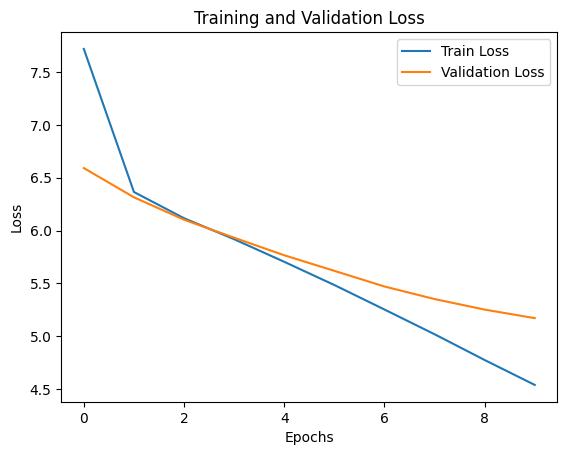

In [40]:
plt.plot(range(len(train_loss_list)), train_loss_list, label='Train Loss')
plt.plot(range(len(val_loss_list)), val_loss_list, label='Validation Loss')
plt.legend()
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.show()

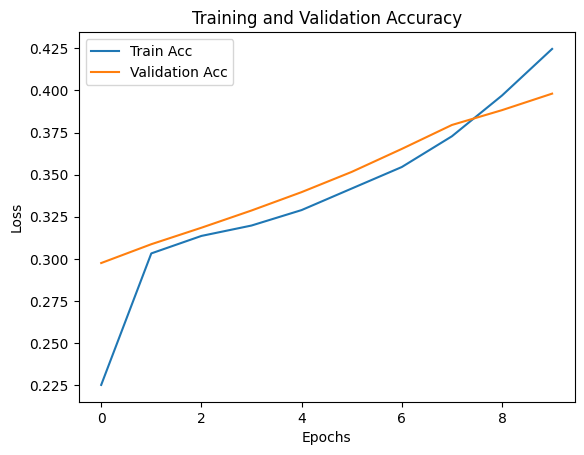

In [41]:
train_acc_list = [train_acc.cpu() for train_acc in train_acc_list]
val_acc_list = [val_acc.cpu() for val_acc in val_acc_list]

plt.plot(range(len(train_acc_list)), train_acc_list, label='Train Acc')
plt.plot(range(len(val_acc_list)), val_acc_list, label='Validation Acc')
plt.legend()
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training and Validation Accuracy")
plt.show()

In [ ]:
def decoder_inference(model, sentence, tokenizer, device='cpu'):
    START_TOKEN = tokenizer.bos_id()
    END_TOKEN = tokenizer.eos_id()
    MAX_LENGTH = 100


    # 전처리
    sentence = preprocess_sentence(sentence)

    # 인코더 입력: [START] + 인코딩 + [END]
    # GPT1은 디코더-온리 모델이므로 enc_input은 사용 x
    
    # 여기 사용 x
=    # enc_input_ids = [START_TOKEN] + tokenizer.encode(sentence) + [END_TOKEN]
    # enc_input = torch.tensor([enc_input_ids], dtype=torch.long, device=device)

    # 디코더 입력(dec_input)을 START_TOKEN만 포함한 상태로 시작
    dec_input = torch.tensor([[START_TOKEN]], dtype=torch.long, device=device)

    model.eval()  # 모델 평가 모드
    with torch.no_grad():
        for i in range(MAX_LENGTH):
            # 모델 forward: (dec_input) -> (batch_size=1, seq_len, vocab_size)
            # GPT1 모델은 enc_input을 받지 않으므로 dec_input만 전달합니다.
            logits = model(dec_input)

            # 마지막 타임스텝의 예측만 추출: shape (1, 1, vocab_size)
            # logits[:, -1, :] -> (1, vocab_size)
            last_step_logits = logits[:, -1, :]

            # argmax로 가장 높은 확률의 토큰 선택
            predicted_id = torch.argmax(last_step_logits, dim=-1)  # shape: (1,)

            # 종료 토큰이면 중단
            if predicted_id.item() == END_TOKEN:
                break

            # 디코더 입력(dec_input)에 예측 토큰을 이어붙임
            predicted_id = predicted_id.unsqueeze(0)  # shape (1,1)
            dec_input = torch.cat([dec_input, predicted_id], dim=1)

    # 최종 시퀀스: dec_input: (1, seq_len)에서 (seq_len,)로
    output_sequence = dec_input.squeeze(0).tolist()  # e.g. [START_TOKEN, ..., 토큰들...]

    return output_sequence

In [61]:
def sentence_generation(model, sentence, tokenizer, device='cpu'):
    # 디코더 인퍼런스 -> 예측된 토큰 시퀀스
    output_seq = decoder_inference(model, sentence, tokenizer, device=device)

    # 토크나이저로 디코딩 (패딩, START/END 토큰 등은 제외하거나 처리)
    # 여기서는 단순히 tokenizer.decode() 직접 호출
    predicted_sentence = tokenizer.decode(
        [token for token in output_seq if token < tokenizer.GetPieceSize()]
    )

    print("입력 :", sentence)
    print("출력 :", predicted_sentence)
    return predicted_sentence

In [62]:
print('============================')
sentence = '안녕?'
sentence_generation(model, sentence, sp, device)
print('============================')
sentence = '하하'
sentence_generation(model, sentence, sp, device)
print('============================')
sentence = '나 너무 슬퍼'
sentence_generation(model, sentence, sp, device)

입력 : 안녕?
출력 : 좋은 결과 있을 거예요 .
입력 : 하하
출력 : 좋은 결과 있을 거예요 .
입력 : 나 너무 슬퍼
출력 : 좋은 결과 있을 거예요 .


'좋은 결과 있을 거예요 .'

## 생각 해보기
- 기존 trasnformer의 encoder-decoder를 단방향의 autoregresssive 한 decoder stack구조로 변경해봄으로써 GPT1에 대한 모델을 구성해볼 수 있었습니다.
- 사실 학습 부족으로 인해 성능에 대한 인퍼런스를 통한 확인을 잘 해보지 못했지만 어느정도 수렴하는 모습들을 확인 해 볼 수 있었습니다.
- 이후, positional embedding을 학습하는것과 transformer처럼 고정 임베딩을 주는것에 대한 비교실험을 통해 성능차이를 확인해보고 싶다는 생각이 들었습니다.
- 또한, 지금은 자연어 데이터이지만 추후에 여러 modal의 데이터가 들어왔을때 그런 정보들을 융합해서 answering을 하거나, 이럴때는 decoder 만의 구조가 불가능 할 것 같다는 생각도 들어서 cross attention의 방향성에 대해서도 고민해보게 되었던것 같습니다.
